# Data preprocessing Analysis
This notebook compares the original and preprocessed datasets for emotion classification.

### Dataset Rebalancing

To improve dataset quality and class imbalance, labels with very low support were removed. The remaining dataset was rebalanced by undersampling the majority classes, reducing the dominance of highly frequent emotions while increasing the relative representation of minority samples.

## Load Libraries

In [13]:
from pathlib import Path
import pandas as pd
import seaborn as sns

REPO_ROOT = Path().resolve().parent

## Load Original and Preprocessed Datasets

In [14]:
orig_path = REPO_ROOT / "ml" / "datasets" / "journaling" / "train.csv"
df_orig = pd.read_csv(orig_path)

aug_path = REPO_ROOT / "ml" / "datasets" / "journaling" / "train_preprocessed.csv"
df_aug = pd.read_csv(aug_path)

print(f"Original dataset shape: {df_orig.shape}")
print(f"Preprocessed dataset shape: {df_aug.shape}")
print(f"Samples removed: {len(df_orig) - len(df_aug)}")
print(f"Retention: {len(df_aug) / len(df_orig):.1%}")

Original dataset shape: (1044, 15)
Preprocessed dataset shape: (444, 15)
Samples removed: 600
Retention: 42.5%


## Compare Label Distributions

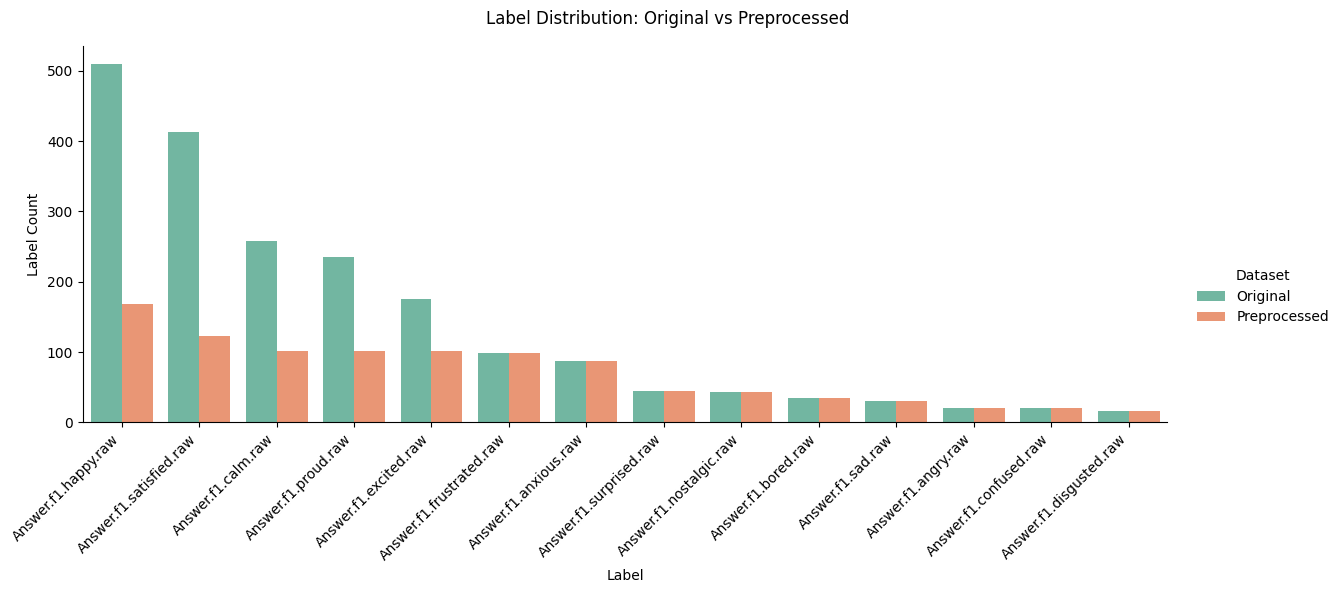

In [15]:
# Extract emotion columns
emotion_cols = [col for col in df_orig.columns if col.startswith("Answer.f1.")]
label_names = [col.replace("Answer.f1.", "").replace(".raw", "") for col in sorted(emotion_cols)]

# Count label occurrences in both datasets
orig_counts = df_orig[emotion_cols].astype(int).sum().sort_values(ascending=False)
aug_counts = df_aug[emotion_cols].astype(int).sum().sort_values(ascending=False)

# Prepare data in long format for seaborn
bar_df = pd.DataFrame(
    {
        "Label": list(orig_counts.index) * 2,
        "Count": list(orig_counts.values) + list(aug_counts.values),
        "Dataset": ["Original"] * len(orig_counts) + ["Preprocessed"] * len(aug_counts),
    }
)

g = sns.catplot(
    data=bar_df,
    x="Label",
    y="Count",
    hue="Dataset",
    kind="bar",
    palette="Set2",
    height=6,
    aspect=2.0,
)
g.set_xticklabels(rotation=45, ha="right")
g.set_axis_labels("Label", "Label Count")
g.figure.suptitle("Label Distribution: Original vs Preprocessed")
g._legend.set_title("Dataset")
g.tight_layout()

## Label Proportion Comparison
Compare the proportion of each label in both datasets.

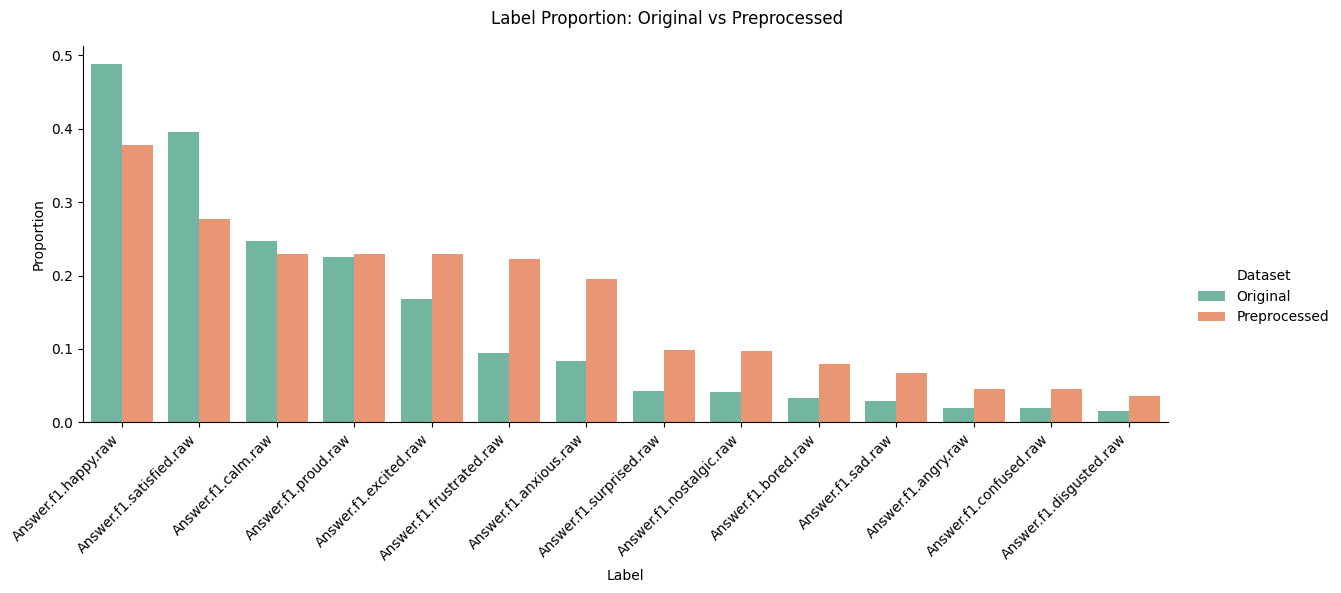

In [17]:
label_order = orig_counts.sort_values(ascending=False).index.tolist()

orig_props = orig_counts / len(df_orig)
aug_props = aug_counts / len(df_aug)

prop_df = pd.DataFrame({"Original": orig_props, "Preprocessed": aug_props})
prop_df = prop_df.reset_index().melt(id_vars="index", var_name="Dataset", value_name="Proportion")
prop_df = prop_df.rename(columns={"index": "Label"})

g = sns.catplot(
    data=prop_df,
    x="Label",
    y="Proportion",
    hue="Dataset",
    kind="bar",
    palette="Set2",
    height=6,
    aspect=2.0,
    order=label_order,
)
g.set_xticklabels(rotation=45, ha="right")
g.set_axis_labels("Label", "Proportion")
g.figure.suptitle("Label Proportion: Original vs Preprocessed")
g.tight_layout()

### Summary

The preprocessing successfully reduced the dominance of the majority labels (*Happy* and *Satisfied*) while preserving the minority labels. As a result, the label distribution became substantially more balanced, reducing the imbalance ratio from approximately 31:1 to 10:1. This provides a more balanced dataset for training and evaluating a multi-label emotion classification model via SetFit.